In [30]:
import torch
print('PyTorch version :', torch.__version__)
print('GPU available   :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name        :', torch.cuda.get_device_name(0))
    print('GPU memory      :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

import subprocess
subprocess.run(['pip', 'install', 'ultralytics', 'timm', '-q'])
print('\nDependencies ready.')

PyTorch version : 2.10.0+cu128
GPU available   : True
GPU name        : Tesla T4
GPU memory      : 15.6 GB

Dependencies ready.


In [32]:
import os

DATASET_SLUG = 'datasets/derrickyebs'  

BASE_PATH     = f'/kaggle/input/{DATASET_SLUG}'
IMAGES_FOLDER = r'/kaggle/input/datasets/derrickyebs/pci-pred/Train/Train'
CSV_PATH = r'/kaggle/input/datasets/derrickyebs/pci-pred/kaggle_ready_train.csv'
OUTPUT_DIR    = '/kaggle/working'                          # all outputs save here

print(f'Base path     : {BASE_PATH}')
print(f'Base exists   : {os.path.isdir(BASE_PATH)}')
print(f'Images folder : {IMAGES_FOLDER}')
print(f'Images exists : {os.path.isdir(IMAGES_FOLDER)}')
print(f'CSV exists    : {os.path.isfile(CSV_PATH)}')

if os.path.isdir(IMAGES_FOLDER):
    imgs = [f for f in os.listdir(IMAGES_FOLDER)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f'Image files   : {len(imgs)}')
else:
    print('\n⚠️  Images folder not found — check your DATASET_SLUG and folder structure')
    print('\nAvailable folders in /kaggle/input:')
    for item in os.listdir('/kaggle/input'):
        print(f'  /kaggle/input/{item}')

Base path     : /kaggle/input/datasets/derrickyebs
Base exists   : True
Images folder : /kaggle/input/datasets/derrickyebs/pci-pred/Train/Train
Images exists : True
CSV exists    : True
Image files   : 7704


In [33]:
from PIL import Image

all_images = [f for f in os.listdir(IMAGES_FOLDER)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f'Scanning {len(all_images)} images for corruption...')

bad_files  = []
good_files = []

for i, fname in enumerate(all_images):
    fpath = os.path.join(IMAGES_FOLDER, fname)
    try:
        img = Image.open(fpath)
        img.verify()
        good_files.append(fname)
    except Exception:
        bad_files.append(fname)
    if (i + 1) % 1000 == 0:
        print(f'  Checked {i+1}/{len(all_images)}...')

print(f'\n✅ Good images : {len(good_files)}')
print(f'❌ Bad images  : {len(bad_files)}')
if bad_files:
    print('Corrupted files (will be excluded):')
    for f in bad_files:
        print(f'  {f}')

Scanning 7704 images for corruption...
  Checked 1000/7704...
  Checked 2000/7704...
  Checked 3000/7704...
  Checked 4000/7704...
  Checked 5000/7704...
  Checked 6000/7704...
  Checked 7000/7704...

✅ Good images : 7702
❌ Bad images  : 2
Corrupted files (will be excluded):
  11980_(40.6916493333333, -89.4393206666667)_ 2023-10-20 16-10-54_28.5085_D.jpg
  1119_(40.7034233333333, -89.4052588333333)_ 2023-10-18 15-49-01_14.30605_D.jpg


Rows loaded : 7704
Columns     : ['image_name', 'pci']
PCI range   : 0 – 100
PCI mean    : 65.39
Nulls       : {'image_name': 0, 'pci': 0}

Sample rows:
                                          image_name  pci
0  10745__40.72376740448161, -89.44599936927897__...  100
1  49812__40.700766104509725, -89.3989279463273__...  100
2  60080_(40.69357, -89.45994)_ 2023-10-20 18-29-...  100
3  2205_(40.7031665, -89.4067306666667)_ 2023-10-...   12
4  28158__40.7079780926376, -89.39486040573811__ ...  100

Rows after filtering: 7702 (removed 2)


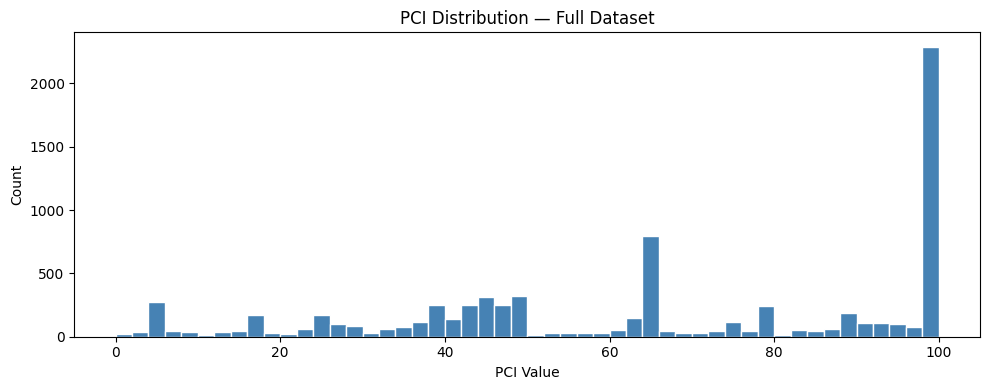

Plot saved.


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(CSV_PATH)
print(f'Rows loaded : {len(df)}')
print(f'Columns     : {df.columns.tolist()}')
print(f'PCI range   : {df["pci"].min()} – {df["pci"].max()}')
print(f'PCI mean    : {df["pci"].mean():.2f}')
print(f'Nulls       : {df.isnull().sum().to_dict()}')
print(f'\nSample rows:')
print(df.head(5))

# This keeps only rows where image exists on disk AND is not corrupted
valid_set = set(good_files)
before    = len(df)
df        = df[df['image_name'].isin(valid_set)].reset_index(drop=True)
print(f'\nRows after filtering: {len(df)} (removed {before - len(df)})')

# PCI distribution
plt.figure(figsize=(10, 4))
plt.hist(df['pci'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('PCI Value'); plt.ylabel('Count')
plt.title('PCI Distribution — Full Dataset')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pci_distribution.png', dpi=150)
plt.show()
print('Plot saved.')

In [35]:
from sklearn.model_selection import train_test_split

df['pci_bin'] = pd.cut(df['pci'], bins=10, labels=False)

df_trainval, df_test = train_test_split(
    df, test_size=0.10, random_state=42, stratify=df['pci_bin']
)
df_train, df_val = train_test_split(
    df_trainval, test_size=0.1111, random_state=42, stratify=df_trainval['pci_bin']
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

total = len(df)
print(f'Train : {len(df_train):,} images ({len(df_train)/total*100:.1f}%)')
print(f'Val   : {len(df_val):,} images ({len(df_val)/total*100:.1f}%)')
print(f'Test  : {len(df_test):,} images ({len(df_test)/total*100:.1f}%)')
print(f'\nPCI mean — Train: {df_train["pci"].mean():.2f} | Val: {df_val["pci"].mean():.2f} | Test: {df_test["pci"].mean():.2f}')

df_train[['image_name','pci']].to_csv(f'{OUTPUT_DIR}/split_train.csv', index=False)
df_val[['image_name','pci']].to_csv(f'{OUTPUT_DIR}/split_val.csv',   index=False)
df_test[['image_name','pci']].to_csv(f'{OUTPUT_DIR}/split_test.csv',  index=False)
print('Split CSVs saved to /kaggle/working/')

Train : 6,160 images (80.0%)
Val   : 771 images (10.0%)
Test  : 771 images (10.0%)

PCI mean — Train: 65.36 | Val: 65.55 | Test: 65.36
Split CSVs saved to /kaggle/working/


In [36]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
print(f'Device: {DEVICE}')

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class PavementDataset(Dataset):
    def __init__(self, dataframe, images_folder, transform=None):
        self.df        = dataframe
        self.folder    = images_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.folder, row['image_name'])
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), color=0)  # black image fallback
        if self.transform:
            image = self.transform(image)
        pci = torch.tensor(float(row['pci']), dtype=torch.float32)
        return image, pci

train_dataset = PavementDataset(df_train, IMAGES_FOLDER, train_transform)
val_dataset   = PavementDataset(df_val,   IMAGES_FOLDER, val_transform)
test_dataset  = PavementDataset(df_test,  IMAGES_FOLDER, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Device: cuda
Train batches : 193
Val batches   : 25
Test batches  : 25


## CBAM ATTENTION MODULE 

In [37]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg = self.fc(self.avg_pool(x))
        mx  = self.fc(self.max_pool(x))
        return self.sigmoid(avg + mx).unsqueeze(2).unsqueeze(3) * x

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg   = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x,  dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1))) * x

class CBAM(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.ca = ChannelAttention(in_channels)
        self.sa = SpatialAttention()
    def forward(self, x):
        return self.sa(self.ca(x))

print('CBAM module ready.')

CBAM module ready.


In [38]:
import torchvision.models as models
import timm

def build_model(name):
    if name == 'resnet50':
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, 1)

    elif name == 'resnet50_cbam':
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.layer4 = nn.Sequential(m.layer4, CBAM(2048))
        m.fc = nn.Linear(m.fc.in_features, 1)

    elif name == 'efficientnet_b0':
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, 1)

    elif name == 'mobilenet_v3':
        m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, 1)

    elif name == 'yolov8_cls':
        backbone = timm.create_model('efficientvit_b0', pretrained=True, num_classes=0)
        feat_dim = backbone.num_features
        m = nn.Sequential(
            backbone,
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
    return m.to(DEVICE)

# Sanity check
dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
for name in ['resnet50', 'efficientnet_b0', 'mobilenet_v3']:
    m   = build_model(name)
    out = m(dummy)
    print(f'{name:20s} output: {out.shape}')
    del m
torch.cuda.empty_cache()

resnet50             output: torch.Size([2, 1])
efficientnet_b0      output: torch.Size([2, 1])
mobilenet_v3         output: torch.Size([2, 1])


In [39]:
# ADDED DENSENET121 
import torchvision.models as models

def build_densenet():
    m = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    
    m.classifier = nn.Linear(m.classifier.in_features, 1)
    return m.to(DEVICE)

# Quick test
dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
test_dense = build_densenet()
out = test_dense(dummy)
print(f'DenseNet121 output shape: {out.shape}')  # should be [2, 1]
del test_dense
torch.cuda.empty_cache()

DenseNet121 output shape: torch.Size([2, 1])


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    r2     = r2_score(y_true, y_pred)
    mask   = y_true != 0   # skip PCI=0 rows to avoid divide by zero in MAPE
    mape   = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {
        'MAPE (%)': round(mape, 2),
        'MAE'     : round(mae,  2),
        'RMSE'    : round(rmse, 2),
        'R2'      : round(r2,   4)
    }

print('Metrics ready. Primary: MAPE | Secondary: MAE, RMSE, R²')

Metrics ready. Primary: MAPE | Secondary: MAE, RMSE, R²


In [43]:
def train_model(model, model_name, epochs=30):
    print(f'\n{"="*60}')
    print(f'  Training: {model_name}')
    print(f'{"="*60}')

    optimizer  = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion  = nn.MSELoss()
    best_mape  = float('inf')

   
    best_path  = f'{OUTPUT_DIR}/best_{model_name}.pt'
    history    = {'train_loss': [], 'val_mape': [], 'val_r2': []}

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            preds = model(imgs).squeeze(1)
            loss  = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        scheduler.step()
        avg_loss = train_loss / len(train_loader)

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                preds = model(imgs.to(DEVICE)).squeeze(1).cpu().numpy()
                val_preds.extend(preds)
                val_true.extend(labels.numpy())

        m = compute_metrics(val_true, val_preds)
        history['train_loss'].append(avg_loss)
        history['val_mape'].append(m['MAPE (%)'])
        history['val_r2'].append(m['R2'])

        print(f'Epoch {epoch:3d}/{epochs} | Loss: {avg_loss:8.4f} | '
              f'Val MAPE: {m["MAPE (%)"]:.2f}% | '
              f'Val MAE: {m["MAE"]:.2f} | '
              f'Val R²: {m["R2"]:.4f}')

        if m['MAPE (%)'] < best_mape:
            best_mape = m['MAPE (%)']
            torch.save(model.state_dict(), best_path)

    print(f'\n✅ Best Val MAPE ({model_name}): {best_mape:.2f}%')
    print(f'   Saved to: {best_path}')

    # Training curve
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(history['train_loss'], color='steelblue', label='Train Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss', color='steelblue')
    ax2 = ax1.twinx()
    ax2.plot(history['val_mape'], color='tomato', label='Val MAPE %')
    ax2.set_ylabel('Val MAPE %', color='tomato')
    plt.title(f'{model_name} — Training Curve')
    fig.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/curve_{model_name}.png', dpi=150)
    plt.show()

    return history, best_path

print('Training loop ready.')

Training loop ready.


In [48]:
def evaluate_on_test(model, model_name, best_path):
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    model.eval()

    test_preds, test_true = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            preds = model(imgs.to(DEVICE)).squeeze(1).cpu().numpy()
            test_preds.extend(preds)
            test_true.extend(labels.numpy())

    test_preds = np.clip(test_preds, 0, 100)
    metrics    = compute_metrics(test_true, test_preds)

    print(f'\n── TEST RESULTS: {model_name} ' + '─'*30)
    for k, v in metrics.items():
        print(f'  {k:10s}: {v}')

    plt.figure(figsize=(6, 6))
    plt.scatter(test_true, test_preds, alpha=0.35, s=12, color='steelblue')
    plt.plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Best fit')
    plt.xlabel('Recorded PCI'); plt.ylabel('Predicted PCI')
    plt.title(f'{model_name}\nMAPE={metrics["MAPE (%)"]:.2f}%  R²={metrics["R2"]}')
    plt.legend(); plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/scatter_{model_name}.png', dpi=150)
    plt.show()

    return metrics

print('Evaluation function ready.')

Evaluation function ready.


## MODEL : RESNET50 (BASELINE)


  Training: ResNet50
Epoch   1/30 | Loss: 2439.2159 | Val MAPE: 53.96% | Val MAE: 26.11 | Val R²: -0.0313
Epoch   2/30 | Loss: 495.2759 | Val MAPE: 51.61% | Val MAE: 14.65 | Val R²: 0.6191
Epoch   3/30 | Loss: 380.0269 | Val MAPE: 58.36% | Val MAE: 13.71 | Val R²: 0.6476
Epoch   4/30 | Loss: 326.7000 | Val MAPE: 54.19% | Val MAE: 13.51 | Val R²: 0.6813
Epoch   5/30 | Loss: 299.3029 | Val MAPE: 56.01% | Val MAE: 12.87 | Val R²: 0.6728
Epoch   6/30 | Loss: 257.0974 | Val MAPE: 47.48% | Val MAE: 12.60 | Val R²: 0.6862
Epoch   7/30 | Loss: 238.0172 | Val MAPE: 54.00% | Val MAE: 12.73 | Val R²: 0.6968
Epoch   8/30 | Loss: 210.7283 | Val MAPE: 57.42% | Val MAE: 12.59 | Val R²: 0.6735
Epoch   9/30 | Loss: 182.4036 | Val MAPE: 49.19% | Val MAE: 12.28 | Val R²: 0.6960
Epoch  10/30 | Loss: 165.2390 | Val MAPE: 54.45% | Val MAE: 12.46 | Val R²: 0.6916
Epoch  11/30 | Loss: 141.7636 | Val MAPE: 48.35% | Val MAE: 12.12 | Val R²: 0.7074
Epoch  12/30 | Loss: 129.6637 | Val MAPE: 53.99% | Val MAE: 12.

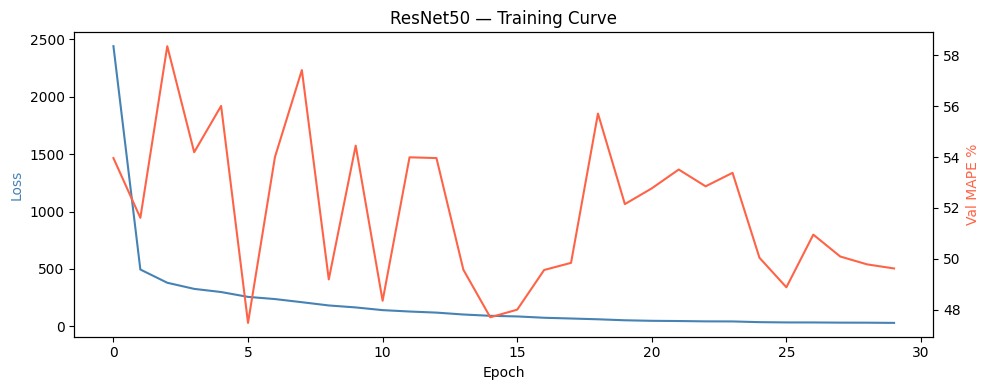

In [20]:
model_resnet50 = build_model('resnet50')
history_r50, path_r50 = train_model(model_resnet50, 'ResNet50', epochs=30)


── TEST RESULTS: ResNet50 ──────────────────────────────
  MAPE (%)  : 47.86
  MAE       : 12.62
  RMSE      : 17.83
  R2        : 0.6671


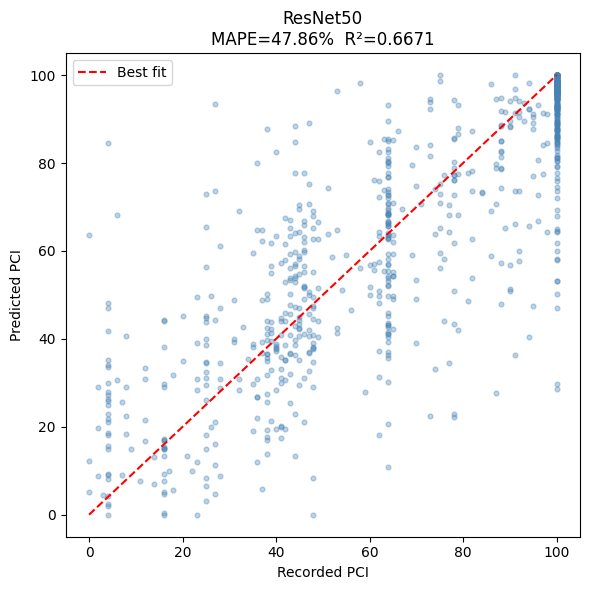

In [55]:
model_resnet50 = build_model('resnet50')
path_r50 = f'{OUTPUT_DIR}/best_ResNet50.pt'
all_results['ResNet50'] = evaluate_on_test(model_resnet50, 'ResNet50', path_r50)

## MODEL : ResNet50 + CBAM


  Training: ResNet50_CBAM
Epoch   1/30 | Loss: 2667.6310 | Val MAPE: 59.35% | Val MAE: 30.67 | Val R²: -0.3379
Epoch   2/30 | Loss: 552.2812 | Val MAPE: 59.58% | Val MAE: 14.56 | Val R²: 0.6204
Epoch   3/30 | Loss: 381.2324 | Val MAPE: 55.66% | Val MAE: 14.38 | Val R²: 0.6464
Epoch   4/30 | Loss: 346.6535 | Val MAPE: 49.62% | Val MAE: 14.94 | Val R²: 0.6369
Epoch   5/30 | Loss: 297.9091 | Val MAPE: 51.00% | Val MAE: 12.78 | Val R²: 0.6847
Epoch   6/30 | Loss: 268.9073 | Val MAPE: 52.88% | Val MAE: 12.28 | Val R²: 0.7120
Epoch   7/30 | Loss: 231.5668 | Val MAPE: 60.26% | Val MAE: 12.92 | Val R²: 0.6691
Epoch   8/30 | Loss: 212.6193 | Val MAPE: 54.85% | Val MAE: 11.86 | Val R²: 0.7148
Epoch   9/30 | Loss: 190.3228 | Val MAPE: 47.82% | Val MAE: 14.07 | Val R²: 0.6737
Epoch  10/30 | Loss: 170.6794 | Val MAPE: 51.89% | Val MAE: 12.47 | Val R²: 0.6864
Epoch  11/30 | Loss: 158.9980 | Val MAPE: 51.10% | Val MAE: 11.59 | Val R²: 0.7181
Epoch  12/30 | Loss: 140.7416 | Val MAPE: 45.61% | Val MAE

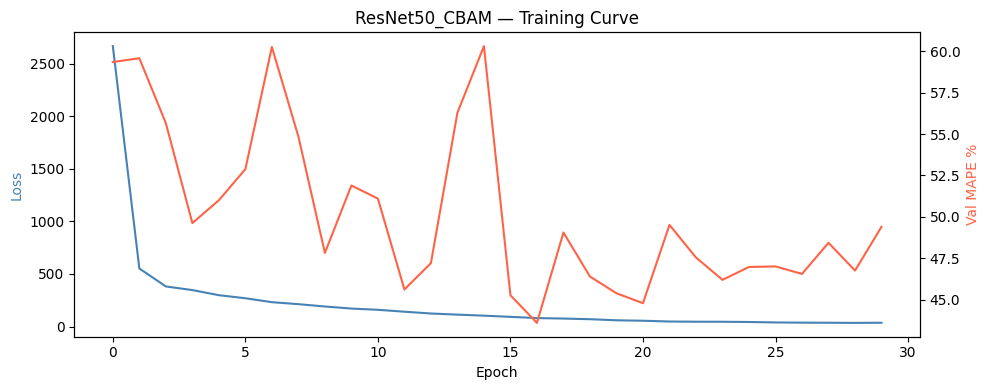

In [45]:
model_cbam = build_model('resnet50_cbam')
history_cbam, path_cbam = train_model(model_cbam, 'ResNet50_CBAM', epochs=30)


── TEST RESULTS: ResNet50_CBAM ──────────────────────────────
  MAPE (%)  : 45.46
  MAE       : 11.53
  RMSE      : 16.49
  R2        : 0.7153


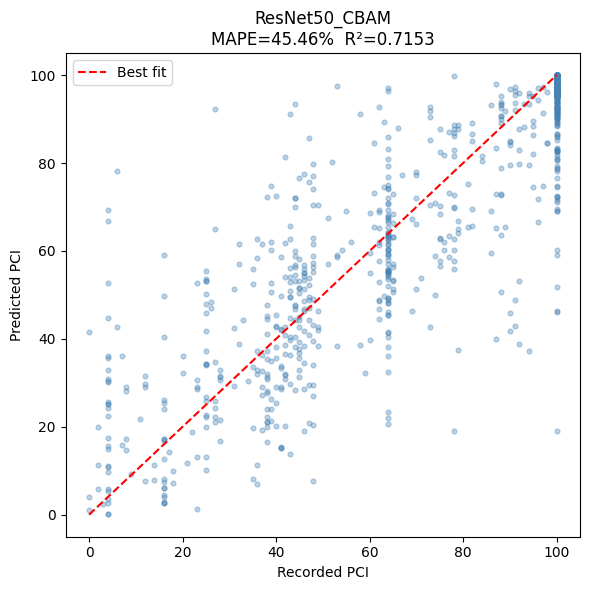

In [49]:
model_cbam = build_model('resnet50_cbam')
path_cbam = f'{OUTPUT_DIR}/best_ResNet50_CBAM.pt'
all_results['ResNet50_CBAM'] = evaluate_on_test(model_cbam, 'ResNet50_CBAM', path_cbam)

## MODEL: EFFICIENTNET-B0


  Training: EfficientNet_B0
Epoch   1/30 | Loss: 4091.0357 | Val MAPE: 80.43% | Val MAE: 49.69 | Val R²: -2.1155
Epoch   2/30 | Loss: 2535.3966 | Val MAPE: 67.47% | Val MAE: 39.23 | Val R²: -1.0081
Epoch   3/30 | Loss: 1739.7411 | Val MAPE: 57.13% | Val MAE: 32.51 | Val R²: -0.4399
Epoch   4/30 | Loss: 1165.2809 | Val MAPE: 49.38% | Val MAE: 23.76 | Val R²: 0.1702
Epoch   5/30 | Loss: 776.5722 | Val MAPE: 47.40% | Val MAE: 19.95 | Val R²: 0.3981
Epoch   6/30 | Loss: 534.7543 | Val MAPE: 47.13% | Val MAE: 16.21 | Val R²: 0.5535
Epoch   7/30 | Loss: 392.9396 | Val MAPE: 46.18% | Val MAE: 14.19 | Val R²: 0.6398
Epoch   8/30 | Loss: 311.3038 | Val MAPE: 45.98% | Val MAE: 12.17 | Val R²: 0.7005
Epoch   9/30 | Loss: 272.7611 | Val MAPE: 46.42% | Val MAE: 11.56 | Val R²: 0.7075
Epoch  10/30 | Loss: 247.1938 | Val MAPE: 49.34% | Val MAE: 11.35 | Val R²: 0.7152
Epoch  11/30 | Loss: 232.5766 | Val MAPE: 50.12% | Val MAE: 11.57 | Val R²: 0.7107
Epoch  12/30 | Loss: 219.7136 | Val MAPE: 46.77% | 

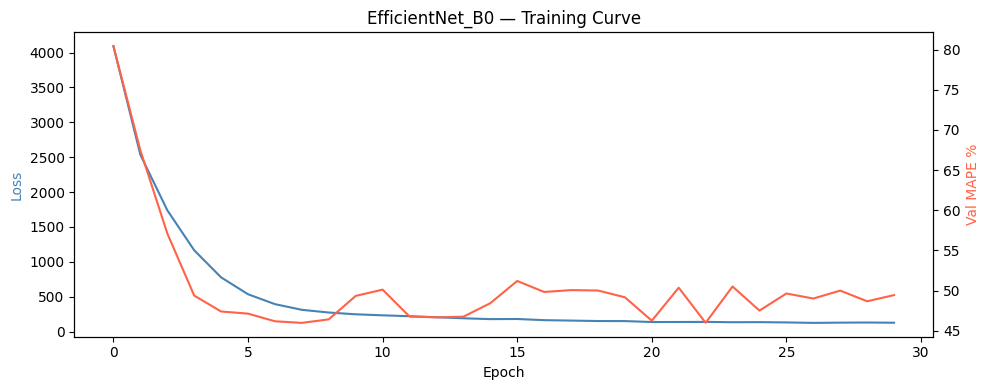

In [50]:
model_effnet = build_model('efficientnet_b0')
history_eff, path_eff = train_model(model_effnet, 'EfficientNet_B0', epochs=30)


── TEST RESULTS: EfficientNet_B0 ──────────────────────────────
  MAPE (%)  : 45.24
  MAE       : 11.63
  RMSE      : 16.63
  R2        : 0.7106


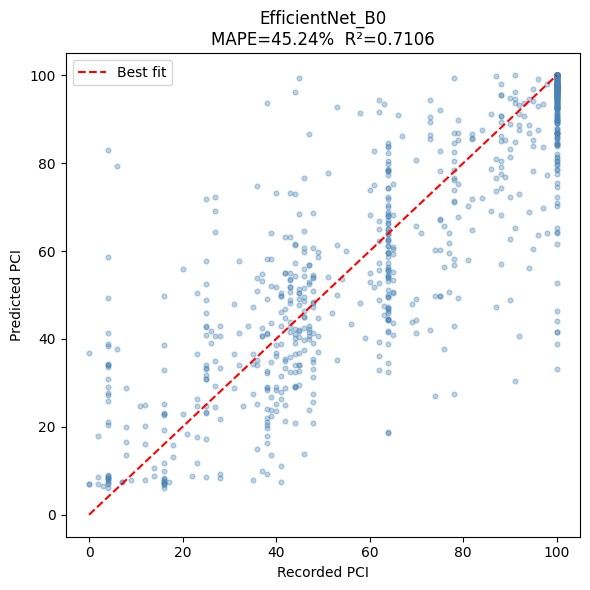

In [51]:
model_effnet = build_model('efficientnet_b0')
path_eff = f'{OUTPUT_DIR}/best_EfficientNet_B0.pt'
all_results['EfficientNet_B0'] = evaluate_on_test(model_effnet, 'EfficientNet_B0', path_eff)

## MODEL: MOBILENETV3


  Training: MobileNetV3
Epoch   1/30 | Loss: 2184.9626 | Val MAPE: 115.58% | Val MAE: 25.79 | Val R²: -0.0314
Epoch   2/30 | Loss: 446.2343 | Val MAPE: 72.27% | Val MAE: 15.04 | Val R²: 0.6066
Epoch   3/30 | Loss: 394.6418 | Val MAPE: 60.98% | Val MAE: 14.27 | Val R²: 0.6215
Epoch   4/30 | Loss: 359.6117 | Val MAPE: 63.03% | Val MAE: 13.61 | Val R²: 0.6363
Epoch   5/30 | Loss: 333.0584 | Val MAPE: 59.07% | Val MAE: 13.47 | Val R²: 0.6563
Epoch   6/30 | Loss: 311.6116 | Val MAPE: 58.22% | Val MAE: 13.37 | Val R²: 0.6473
Epoch   7/30 | Loss: 299.2852 | Val MAPE: 63.90% | Val MAE: 13.89 | Val R²: 0.6463
Epoch   8/30 | Loss: 280.8981 | Val MAPE: 58.59% | Val MAE: 13.61 | Val R²: 0.6505
Epoch   9/30 | Loss: 265.6330 | Val MAPE: 57.75% | Val MAE: 13.12 | Val R²: 0.6610
Epoch  10/30 | Loss: 256.3661 | Val MAPE: 57.14% | Val MAE: 12.86 | Val R²: 0.6661
Epoch  11/30 | Loss: 240.6379 | Val MAPE: 52.53% | Val MAE: 13.19 | Val R²: 0.6590
Epoch  12/30 | Loss: 233.5273 | Val MAPE: 56.36% | Val MAE:

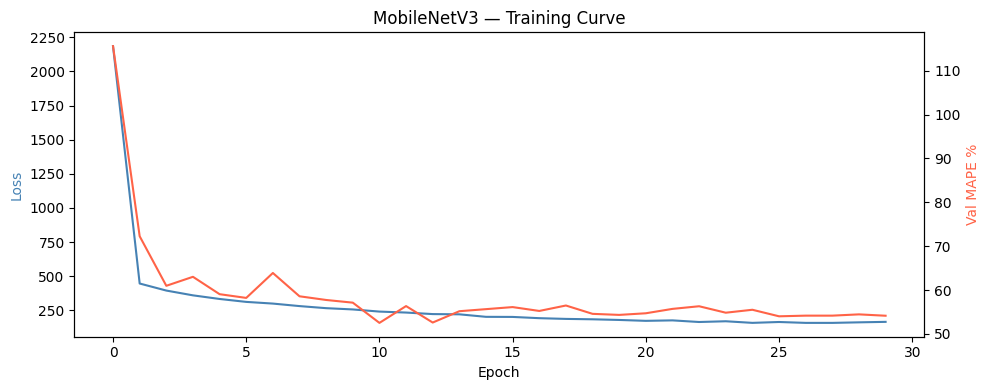

In [56]:
model_mobile = build_model('mobilenet_v3')
history_mob, path_mob = train_model(model_mobile, 'MobileNetV3', epochs=30)


── TEST RESULTS: MobileNetV3 ──────────────────────────────
  MAPE (%)  : 52.97
  MAE       : 13.03
  RMSE      : 17.82
  R2        : 0.6674


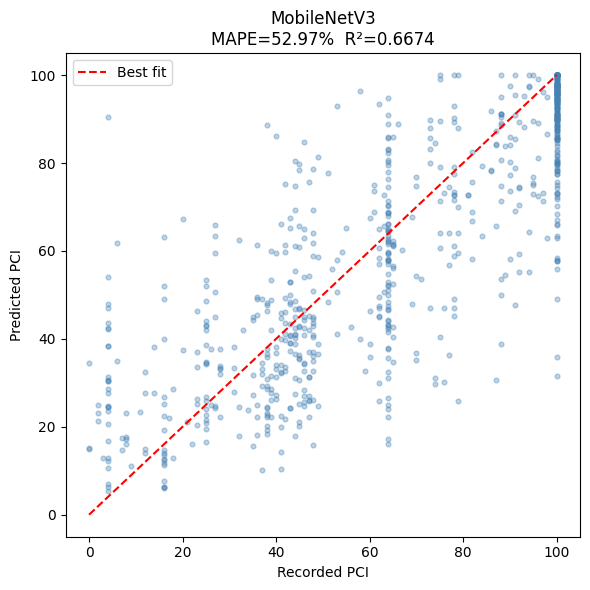

In [57]:
model_mobile = build_model('mobilenet_v3')
path_mob = f'{OUTPUT_DIR}/best_MobileNetV3.pt'
all_results['MobileNetV3'] = evaluate_on_test(model_mobile, 'MobileNetV3', path_mob)

## MODEL : DENSENET121


  Training: DenseNet121
Epoch   1/30 | Loss: 4200.3826 | Val MAPE: 98.74% | Val MAE: 54.94 | Val R²: -2.6864
Epoch   2/30 | Loss: 2824.2444 | Val MAPE: 67.39% | Val MAE: 42.19 | Val R²: -1.2664
Epoch   3/30 | Loss: 1764.1340 | Val MAPE: 54.22% | Val MAE: 30.94 | Val R²: -0.2735
Epoch   4/30 | Loss: 990.6823 | Val MAPE: 49.19% | Val MAE: 23.08 | Val R²: 0.2320
Epoch   5/30 | Loss: 556.4660 | Val MAPE: 43.13% | Val MAE: 16.06 | Val R²: 0.5935
Epoch   6/30 | Loss: 357.8937 | Val MAPE: 45.31% | Val MAE: 13.09 | Val R²: 0.6873
Epoch   7/30 | Loss: 287.8373 | Val MAPE: 49.81% | Val MAE: 12.29 | Val R²: 0.7099
Epoch   8/30 | Loss: 251.5911 | Val MAPE: 52.85% | Val MAE: 12.08 | Val R²: 0.6803
Epoch   9/30 | Loss: 232.7316 | Val MAPE: 49.69% | Val MAE: 11.47 | Val R²: 0.7127
Epoch  10/30 | Loss: 212.9524 | Val MAPE: 42.12% | Val MAE: 11.73 | Val R²: 0.7358
Epoch  11/30 | Loss: 199.8671 | Val MAPE: 50.62% | Val MAE: 11.01 | Val R²: 0.7151
Epoch  12/30 | Loss: 177.9205 | Val MAPE: 46.09% | Val M

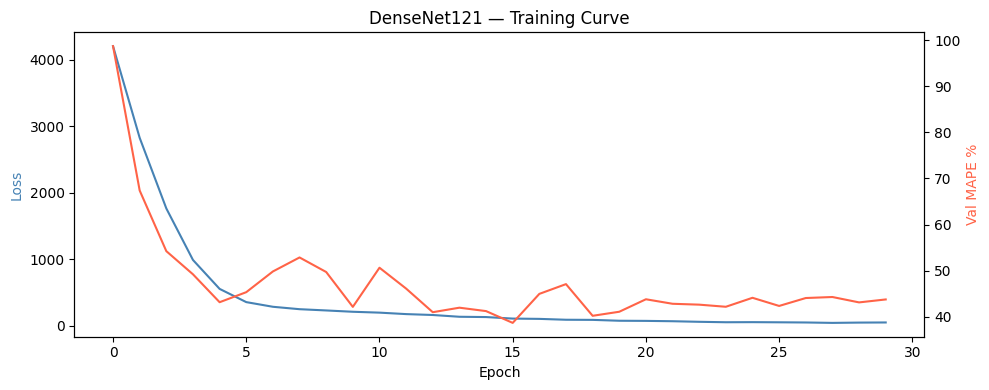

In [53]:
model_densenet = build_densenet()
history_dense, path_dense = train_model(model_densenet, 'DenseNet121', epochs=30)


── TEST RESULTS: DenseNet121 ──────────────────────────────
  MAPE (%)  : 43.79
  MAE       : 10.23
  RMSE      : 15.9
  R2        : 0.7353


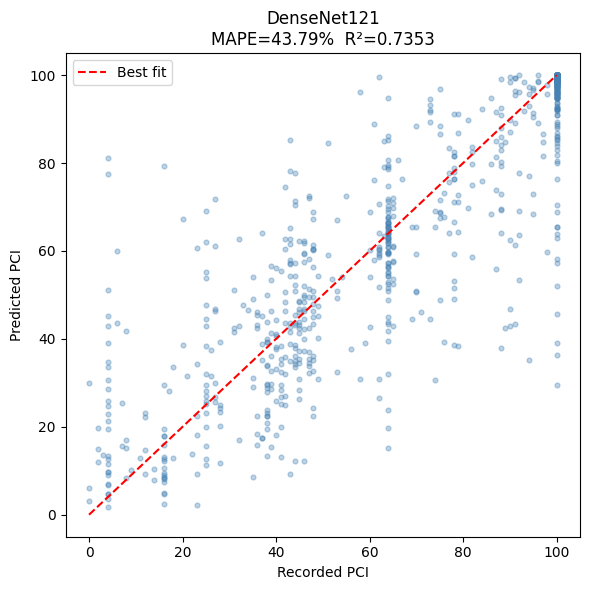

In [54]:
model_densenet = build_densenet()
path_dense = f'{OUTPUT_DIR}/best_DenseNet121.pt'
all_results['DenseNet121'] = evaluate_on_test(model_densenet, 'DenseNet121', path_dense)